In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# [1] Cấu hình thư mục gốc 
DATA_DIR = "/data/raw"

# Nhóm Bảng chính (Main Tables)
MAIN_TRAIN_FILE = os.path.join(DATA_DIR, "application_train.csv")
MAIN_TEST_FILE  = os.path.join(DATA_DIR, "application_test.csv")

# Nhóm Luồng lịch sử BÊN NGOÀI Home Credit (Credit Bureau Stream)
BUREAU_FILE      = os.path.join(DATA_DIR, "bureau.csv")
BUREAU_BAL_FILE  = os.path.join(DATA_DIR, "bureau_balance.csv")

# Nhóm Luồng lịch sử BÊN TRONG Home Credit (Internal Behavioral Stream)
PREV_APP_FILE    = os.path.join(DATA_DIR, "previous_application.csv")
INS_PAYMENT_FILE = os.path.join(DATA_DIR, "installments_payments.csv")
POS_CASH_FILE    = os.path.join(DATA_DIR, "POS_CASH_balance.csv")
CREDIT_CARD_FILE = os.path.join(DATA_DIR, "credit_card_balance.csv")

# File phụ bổ sung thông tin mô tả
COL_DESC_FILE    = os.path.join(DATA_DIR, "HomeCredit_columns_description.csv")

In [2]:
# =========================================================================
# KHỐI ETL ĐỒNG BỘ ĐỘNG 100% TỪ FILE DATALIST.CSV UPLOAD ĐỂ VÁ LỖI TARGET
# =========================================================================
import os
import pandas as pd
import numpy as np

DATA_DIR = "/data/raw"
CONFIG_FILE = '../Datalist.csv'

if not os.path.exists(CONFIG_FILE):
    raise FileNotFoundError(f"❌ Không tìm thấy file {CONFIG_FILE} trong thư mục hiện tại. Trí kiểm tra lại nhé!")

print("🔄 Đang quét trực tiếp file Datalist.csv xịn của Trí...")
df_config = pd.read_csv(CONFIG_FILE, encoding='utf-8')

# Dọn dẹp khoảng trắng thừa trong cấu hình
for col in df_config.columns:
    df_config[col] = df_config[col].astype(str).str.strip()

# Chuẩn hóa tên bảng application về đúng file vật lý train để đọc dữ liệu
df_config['Table'] = df_config['Table'].str.replace('application_{train|test}.csv', 'application_train.csv', regex=False)

# 🎯 ĐẢM BẢO CHỈ BỐC ĐÚNG NHỮNG DÒNG ĐƯỢC KEEP (100% KHỚP FILE NOTION)
df_keep = df_config[df_config['Phân loại chiến lược'].str.contains('Keep', na=False, case=False)]
notion_keep_config = df_keep.groupby('Table')['Row'].apply(list).to_dict()

# Bắt buộc phải cài cắm khóa chính và TARGET vào bảng application nếu file bị khuyết
if 'application_train.csv' in notion_keep_config:
    if 'SK_ID_CURR' not in notion_keep_config['application_train.csv']:
        notion_keep_config['application_train.csv'].append('SK_ID_CURR')
    if 'TARGET' not in notion_keep_config['application_train.csv']:
        notion_keep_config['application_train.csv'].append('TARGET')

table_prefixes = {
    'bureau.csv': 'BUREAU_', 'bureau_balance.csv': 'BB_', 'previous_application.csv': 'PREV_',
    'POS_CASH_balance.csv': 'POS_', 'installments_payments.csv': 'INSTAL_', 'credit_card_balance.csv': 'CC_'
}

# -------------------------------------------------------------------------
# TIẾN TRÌNH 1: XỬ LÝ RIÊNG BIỆT BẢNG PHỤ TRÙNG KHÓA NGOẠI (BUREAU BALANCE)
# -------------------------------------------------------------------------
df_bureau_balance_agg = None
if 'bureau_balance.csv' in notion_keep_config:
    file_path = os.path.join(DATA_DIR, 'bureau_balance.csv')
    if os.path.exists(file_path):
        print("📥 Đang nén phẳng dữ liệu chuỗi thời gian: bureau_balance.csv...")
        cols_bb = list(set(notion_keep_config['bureau_balance.csv'] + ['SK_ID_BUREAU']))
        df_bb = pd.read_csv(file_path, usecols=cols_bb)
        num_bb = df_bb.select_dtypes(include=['number']).columns.tolist()
        if 'SK_ID_BUREAU' in num_bb: num_bb.remove('SK_ID_BUREAU')
        
        df_bureau_balance_agg = df_bb.groupby('SK_ID_BUREAU')[num_bb].mean().reset_index()
        prefix = table_prefixes['bureau_balance.csv']
        df_bureau_balance_agg.columns = ['SK_ID_BUREAU'] + [f"{prefix}{c}" for c in df_bureau_balance_agg.columns if c != 'SK_ID_BUREAU']

# -------------------------------------------------------------------------
# TIẾN TRÌNH 2: VÒNG LẶP PIPELINE ĐÚC MA TRẬN PHẲNG TỔNG CỤC
# -------------------------------------------------------------------------
df_final_eda_matrix = None
table_order = ['application_train.csv', 'bureau.csv', 'previous_application.csv', 'POS_CASH_balance.csv', 'installments_payments.csv', 'credit_card_balance.csv']

for table_name in table_order:
    if table_name not in notion_keep_config: continue
    file_path = os.path.join(DATA_DIR, table_name)
    if not os.path.exists(file_path): continue
        
    cols_to_load = notion_keep_config[table_name].copy()
    if 'SK_ID_CURR' not in cols_to_load: cols_to_load.append('SK_ID_CURR')
    if table_name == 'bureau.csv' and 'SK_ID_BUREAU' not in cols_to_load: cols_to_load.append('SK_ID_BUREAU')
    cols_to_load = list(set([c.strip() for c in cols_to_load]))
    
    print(f"📥 Đang bóc tách cột tự động từ file vật lý: {table_name}...")
    df_chunk = pd.read_csv(file_path, usecols=cols_to_load)
    
    if table_name == 'bureau.csv' and df_bureau_balance_agg is not None:
        print("   ↳ [Đồng bộ CIC] Khớp nối số dư tài khoản ngoại hệ thống vào bảng bureau...")
        df_chunk = df_chunk.merge(df_bureau_balance_agg, on='SK_ID_BUREAU', how='left')
    
    # NÉN PHẲNG THEO MÃ KHÁCH HÀNG 1 DÒNG / 1 USER
    if table_name != 'application_train.csv':
        print(f"   ↳ [Xử lý Một - Nhiều] Đang tối ưu gom nhóm cấu trúc cho '{table_name}'...")
        num_cols = df_chunk.select_dtypes(include=['number']).columns.tolist()
        for idx_col in ['SK_ID_CURR', 'SK_ID_PREV', 'SK_ID_BUREAU']:
            if idx_col in num_cols: num_cols.remove(idx_col)
            
        df_chunk_agg = df_chunk.groupby('SK_ID_CURR')[num_cols].mean().reset_index()
        
        cat_cols = df_chunk.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
        if cat_cols:
            df_chunk_cat = df_chunk.groupby('SK_ID_CURR')[cat_cols].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan).reset_index()
            df_chunk_agg = df_chunk_agg.merge(df_chunk_cat, on='SK_ID_CURR', how='left')
            
        # Gắn tiền tố (Prefix) viết tắt để không bị đè mất cột trùng tên kinh tế
        prefix = table_prefixes[table_name]
        renamed_cols = {'SK_ID_CURR': 'SK_ID_CURR'}
        for col in df_chunk_agg.columns:
            if col != 'SK_ID_CURR': renamed_cols[col] = f"{prefix}{col}"
        df_chunk_agg = df_chunk_agg.rename(columns=renamed_cols)
        df_chunk = df_chunk_agg

    # Tiến hành liên kết phẳng
    if df_final_eda_matrix is None:
        df_final_eda_matrix = df_chunk
    else:
        df_final_eda_matrix = df_final_eda_matrix.merge(df_chunk, on='SK_ID_CURR', how='left')

print("\n" + "="*70)
print(f"✅ THÀNH CÔNG RỰC RỠ: Ma trận tổng phẳng đã lên sóng!")
print(f"📊 Kích thước chuẩn chỉnh kịch trần: {df_final_eda_matrix.shape[0]:,} dòng × {df_final_eda_matrix.shape[1]} cột.")
print(f"🎯 Trạng thái kiểm tra cột TARGET: {'CÓ MẶT (Sẵn sàng vẽ hình)' if 'TARGET' in df_final_eda_matrix.columns else 'THIẾU (Lỗi)'}")

🔄 Đang quét trực tiếp file Datalist.csv xịn của Trí...
📥 Đang nén phẳng dữ liệu chuỗi thời gian: bureau_balance.csv...
📥 Đang bóc tách cột tự động từ file vật lý: application_train.csv...
📥 Đang bóc tách cột tự động từ file vật lý: bureau.csv...
   ↳ [Đồng bộ CIC] Khớp nối số dư tài khoản ngoại hệ thống vào bảng bureau...
   ↳ [Xử lý Một - Nhiều] Đang tối ưu gom nhóm cấu trúc cho 'bureau.csv'...
📥 Đang bóc tách cột tự động từ file vật lý: previous_application.csv...
   ↳ [Xử lý Một - Nhiều] Đang tối ưu gom nhóm cấu trúc cho 'previous_application.csv'...
📥 Đang bóc tách cột tự động từ file vật lý: POS_CASH_balance.csv...
   ↳ [Xử lý Một - Nhiều] Đang tối ưu gom nhóm cấu trúc cho 'POS_CASH_balance.csv'...
📥 Đang bóc tách cột tự động từ file vật lý: installments_payments.csv...
   ↳ [Xử lý Một - Nhiều] Đang tối ưu gom nhóm cấu trúc cho 'installments_payments.csv'...
📥 Đang bóc tách cột tự động từ file vật lý: credit_card_balance.csv...
   ↳ [Xử lý Một - Nhiều] Đang tối ưu gom nhóm cấu trú

🔤 Hệ thống phát hiện tổng cộng 19 biến chữ sau khi đồng bộ tiền tố.
🔄 Đang dựng lưới đồ thị 100% Stacked Bar toàn diện...


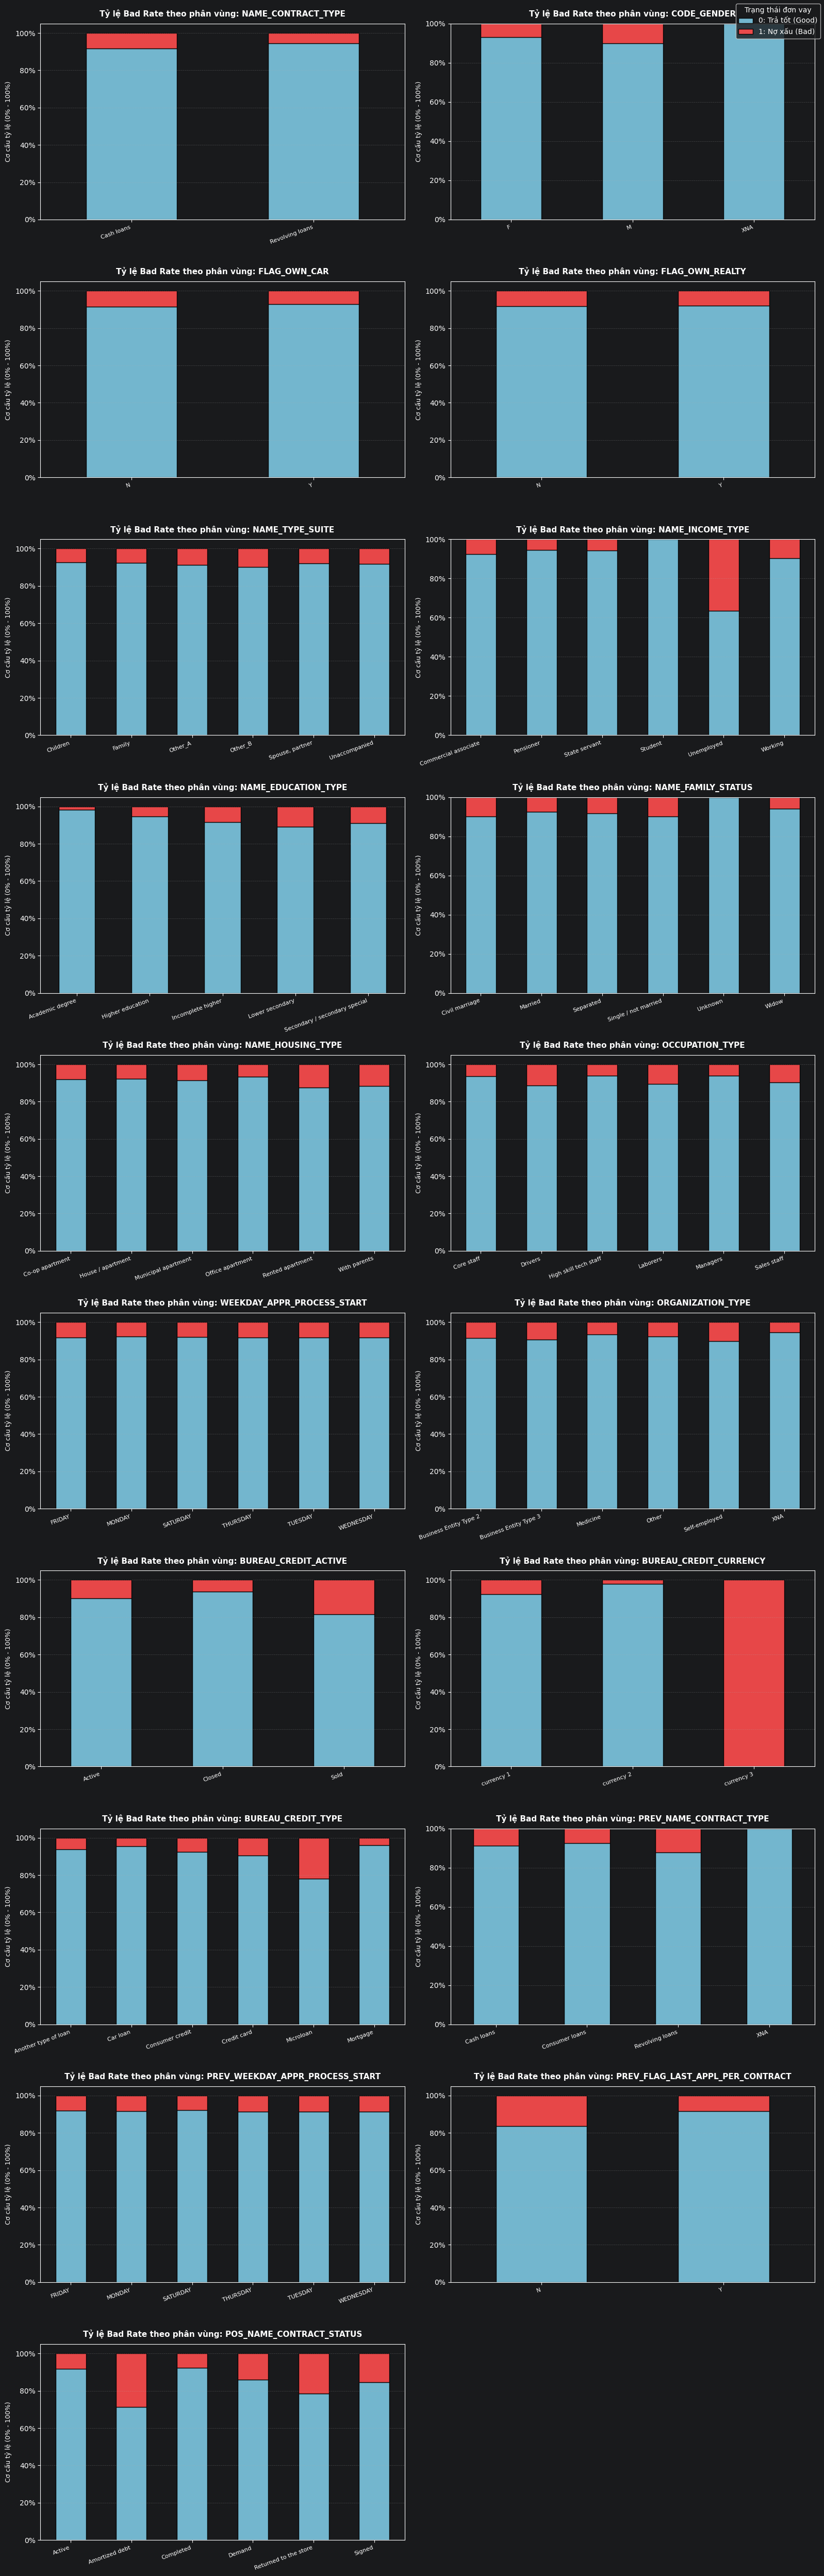

🏆 Hoàn tất kết xuất lưới đồ thị phân tích toàn diện biến chữ!


In [3]:
# =========================================================================
# CELL 1: ĐỒ THỊ THANH CHỒNG 100% (STACKED BAR) - PHÂN TÍCH TOÀN BỘ BIẾN CHỮ
# =========================================================================
import pandas as pd
import matplotlib.pyplot as plt

target_col = 'TARGET'

# Đồng bộ hóa kiểu dữ liệu chuỗi cho TARGET để kết xuất đồ họa chuẩn xác
df_final_eda_matrix[target_col] = df_final_eda_matrix[target_col].astype(str).str.replace(r'\.0$', '', regex=True)

# Lọc danh sách biến chữ thực tế từ ma trận tổng (đã loại bỏ ID và TARGET)
cols_to_plot = [c for c in df_final_eda_matrix.columns if 'ID' not in c.upper() and c != target_col]
cat_feats = [c for c in cols_to_plot if not pd.api.types.is_numeric_dtype(df_final_eda_matrix[c])]

print(f"🔤 Hệ thống phát hiện tổng cộng {len(cat_feats)} biến chữ sau khi đồng bộ tiền tố.")
print("🔄 Đang dựng lưới đồ thị 100% Stacked Bar toàn diện...")

if cat_feats:
    n_cols = 2
    # Tự động tính toán số hàng để chứa đủ 100% tất cả biến chữ phát hiện được
    n_rows = (len(cat_feats) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, n_rows * 5))
    axes = axes.flatten()
    
    for idx, col in enumerate(cat_feats):
        ax = axes[idx]
        
        # Tạo bảng chéo và chuẩn hóa theo dòng (kéo phẳng cơ cấu về 100%)
        ct = pd.crosstab(df_final_eda_matrix[col], df_final_eda_matrix[target_col], normalize='index')
        
        # Chỉ lấy top 6 nhóm xuất hiện nhiều nhất để nhãn chữ đồ thị không bị dính vào nhau
        top_labels = df_final_eda_matrix[col].value_counts().nlargest(6).index
        ct_filtered = ct.loc[ct.index.isin(top_labels)]
        
        # Vẽ cột chồng cơ cấu rủi ro tín dụng
        ct_filtered.plot(
            kind='bar', stacked=True, color=['#7ec8e3', '#ff4d4d'], 
            ax=ax, width=0.5, edgecolor='black', alpha=0.9
        )
        
        # Gắn tiêu đề bao gồm cả tiền tố phân vùng bảng để dễ nhận biết khu vực dữ liệu
        ax.set_title(f'Tỷ lệ Bad Rate theo phân vùng: {col}', fontsize=11, fontweight='bold', pad=10)
        ax.set_xlabel('')
        ax.set_ylabel('Cơ cấu tỷ lệ (0% - 100%)', fontsize=9)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
        
        # Định dạng tỷ lệ phần trăm trực quan trên trục Y
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x*100)}%'))
        ax.get_legend().remove()
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
    # Thiết lập bảng chú thích (Legend) tổng thể ở góc trên cùng
    fig.legend(['0: Trả tốt (Good)', '1: Nợ xấu (Bad)'], loc='upper right', title="Trạng thái đơn vay", fontsize=10)
    
    # Dọn dẹp các ô lưới trống thừa nếu tổng số biến chữ là số lẻ
    for i in range(idx + 1, len(axes)): fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()
    print("🏆 Hoàn tất kết xuất lưới đồ thị phân tích toàn diện biến chữ!")
else:
    print("⚠️ Không tìm thấy biến chữ định danh nào phù hợp để vẽ đồ thị.")

📈 Hệ thống phát hiện tổng cộng 73 biến số sau khi đồng bộ tiền tố.
🔄 Đang dựng lưới đồ thị Boxplot dải phân vị so sánh rủi ro...


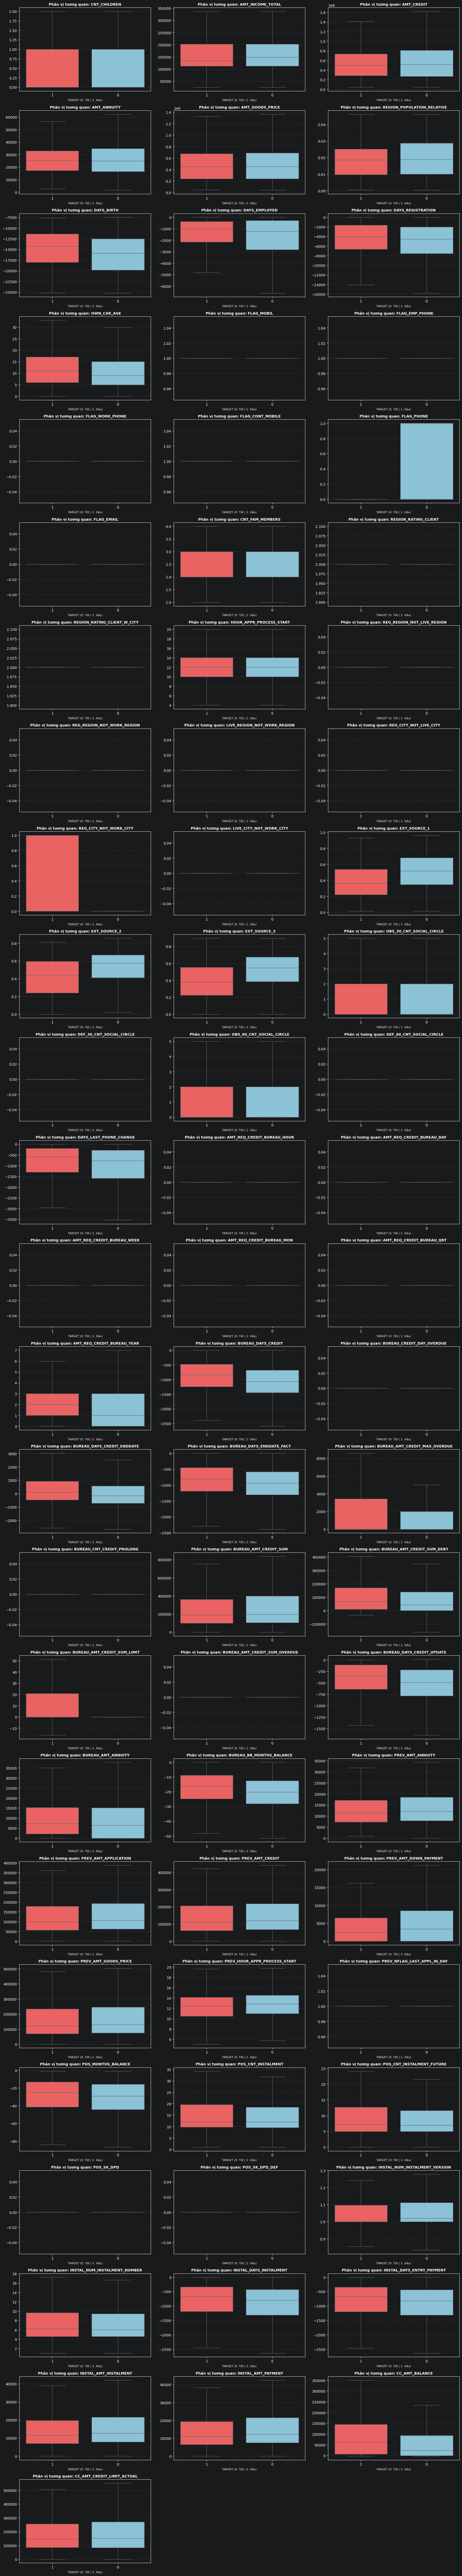

🏆 Hoàn tất kết xuất lưới đồ thị phân tích dải phân vị toàn bộ biến số!


In [4]:
# =========================================================================
# CELL 2: ĐỒ THỊ HỘP (BOXPLOT TỐI ƯU CỰC ĐẠI) - PHÂN TÍCH TOÀN BỘ BIẾN SỐ
# =========================================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'TARGET'

# Lọc danh sách biến số thực tế từ ma trận tổng (đã loại bỏ ID và TARGET)
cols_to_plot = [c for c in df_final_eda_matrix.columns if 'ID' not in c.upper() and c != target_col]
num_feats = [c for c in cols_to_plot if pd.api.types.is_numeric_dtype(df_final_eda_matrix[c])]

print(f"📈 Hệ thống phát hiện tổng cộng {len(num_feats)} biến số sau khi đồng bộ tiền tố.")
print("🔄 Đang dựng lưới đồ thị Boxplot dải phân vị so sánh rủi ro...")

if num_feats:
    n_cols = 3
    # Tự động tính toán số hàng dựa trên tổng số biến số thực tế được giữ lại
    n_rows = (len(num_feats) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()
    
    for idx, col in enumerate(num_feats):
        ax = axes[idx]
        
        # Vẽ biểu đồ hộp phân biệt rạch ròi 2 nhóm khách hàng 0 và 1
        sns.boxplot(
            data=df_final_eda_matrix, x=target_col, y=col, 
            hue=target_col,
            palette={'0': '#7ec8e3', '1': '#ff4d4d'}, ax=ax,
            showfliers=False, legend=False
        )
        
        # Hiển thị rõ tên trường kết hợp tiền tố bảng để đối chiếu xu hướng
        ax.set_title(f'Phân vị tương quan: {col}', fontsize=10, fontweight='bold')
        ax.set_xlabel('TARGET (0: Tốt | 1: Xấu)', fontsize=8)
        ax.set_ylabel('')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        
    # Xóa bỏ toàn bộ các ô đồ thị trống thừa ở hàng cuối cùng của lưới dữ liệu
    for i in range(idx + 1, len(axes)): fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()
    print("🏆 Hoàn tất kết xuất lưới đồ thị phân tích dải phân vị toàn bộ biến số!")
else:
    print("⚠️ Không tìm thấy biến số liên tục nào phù hợp để vẽ đồ thị.")


📈 2. DỰNG MA TRẬN TƯƠNG QUAN PEARSON (CORRELATION HEATMAP) CHO BIẾN SỐ...


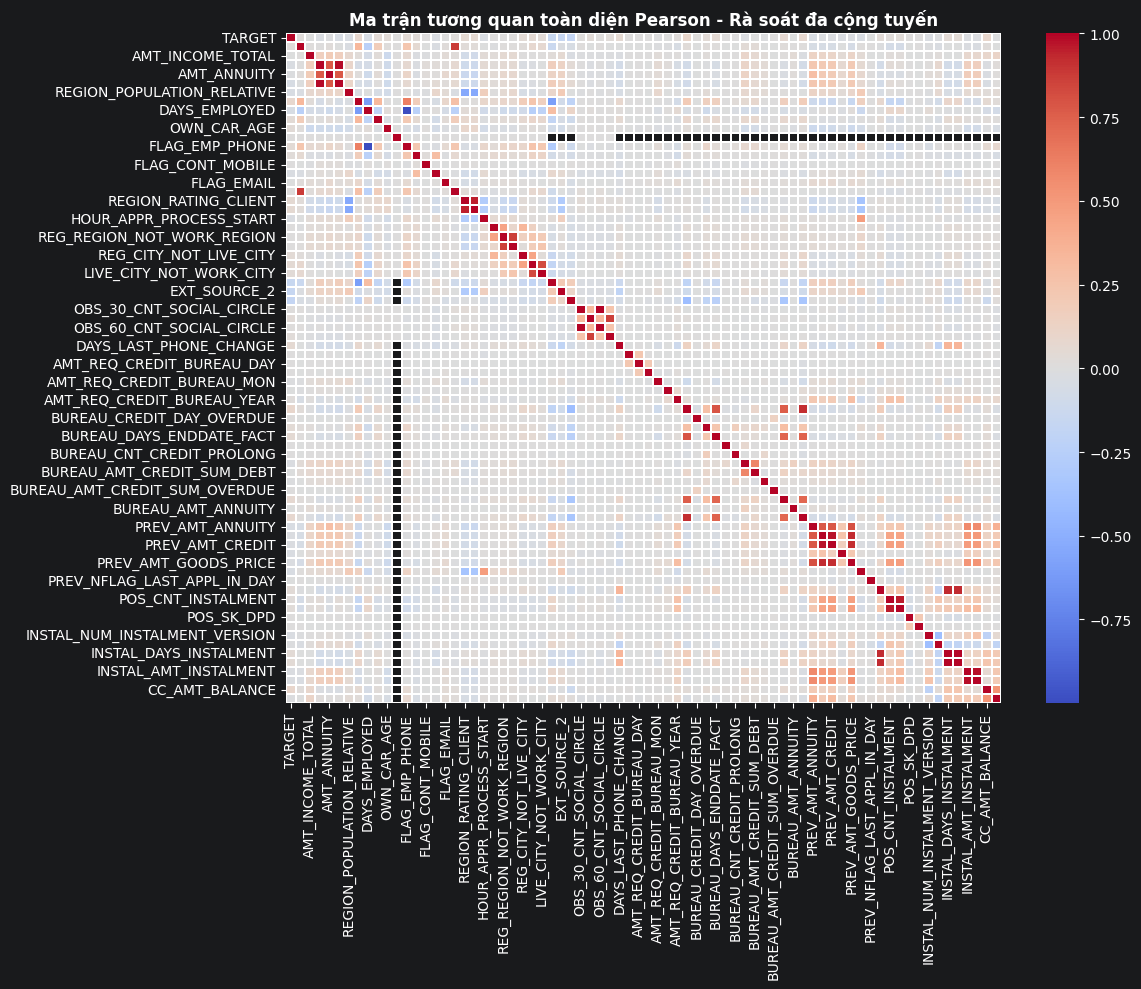


💾 3. TIẾN TRÌNH ĐÓNG GÓI MA TRẬN PHẲNG SẠCH RA Ổ CỨNG...
👉 /Users/nguyenminhtri/FinalYearPro/data/processed/df_final_eda_matrix.csv


In [5]:
# =========================================================================
# CELL CHỐT HẠ GIAI ĐOẠN EDA: KIỂM TRA MA TRẬN TƯƠNG QUAN, RỖNG VÀ ĐÓNG GÓI
# =========================================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



print("\n📈 2. DỰNG MA TRẬN TƯƠNG QUAN PEARSON (CORRELATION HEATMAP) CHO BIẾN SỐ...")
# Chỉ lọc các biến số liên tục (loại bỏ ID và ép Target về số nếu đang ở dạng chuỗi)
num_cols = [c for c in df_final_eda_matrix.columns if 'ID' not in c.upper()]
df_num_corr = df_final_eda_matrix[num_cols].copy()
if 'TARGET' in df_num_corr.columns:
    df_num_corr['TARGET'] = df_num_corr['TARGET'].astype(float)
df_num_corr = df_num_corr.select_dtypes(include=['number'])

# Tính toán ma trận tương quan
corr_matrix = df_num_corr.corr()

# Vẽ Heatmap thu nhỏ các biến có tương quan mạnh với TARGET
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.1)
plt.title("Ma trận tương quan toàn diện Pearson - Rà soát đa cộng tuyến", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💾 3. TIẾN TRÌNH ĐÓNG GÓI MA TRẬN PHẲNG SẠCH RA Ổ CỨNG...")
output_path = "/data/processed/df_final_eda_matrix.csv"
# Tự động tạo thư mục processed nếu chưa có
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Xuất file lưu trữ
df_final_eda_matrix.to_csv(output_path, index=False)
print(f"👉 {output_path}")


In [7]:
import numpy as np
import pandas as pd

def calculate_iv_categorical(df, feature, target):
    """Tính chỉ số Information Value (IV) cho một biến chữ"""
    # Tạo bảng chéo đếm số ca nhãn 0 và nhãn 1
    lst = []
    for i in df[feature].unique():
        if pd.isna(i): continue
        df_feat = df[df[feature] == i]
        goods = len(df_feat[df_feat[target] == 0])
        bads = len(df_feat[df_feat[target] == 1])
        lst.append([feature, i, goods, bads])
        
    data = pd.DataFrame(lst, columns=['Variable', 'Value', 'Good', 'Bad'])
    
    # Loại bỏ các nhóm không có dữ liệu để tránh chia cho 0
    data = data[(data['Good'] > 0) & (data['Bad'] > 0)]
    
    # Tính tỷ lệ cơ cấu
    total_goods = df[target].value_counts()[0]
    total_bads = df[target].value_counts()[1]
    
    data['Dist_Good'] = data['Good'] / total_goods
    data['Dist_Bad'] = data['Bad'] / total_bads
    
    # Công thức toán học của WoE và IV
    data['WoE'] = np.log(data['Dist_Good'] / data['Dist_Bad'])
    data['IV_Component'] = (data['Dist_Good'] - data['Dist_Bad']) * data['WoE']
    
    return data['IV_Component'].sum()

# 🎯 Tiến hành quét toàn bộ biến chữ trong ma trận phẳng của Trí
target_col = 'TARGET'
# Ép Target về dạng số nguyên để tính toán chuẩn xác
df_iv_calc = df_final_eda_matrix.copy()
df_iv_calc[target_col] = df_iv_calc[target_col].astype(int)

# Lọc ra danh sách các cột chữ (object/category/string)
cat_cols = [c for c in df_iv_calc.select_dtypes(include=['object', 'category', 'string']).columns if c != target_col]

iv_results = []
for col in cat_cols:
    iv_val = calculate_iv_categorical(df_iv_calc, col, target_col)
    # Quy ước phân loại sức mạnh IV trong ngành Ngân hàng
    if iv_val < 0.02: power = "Yếu (Sắp loại)"
    elif iv_val < 0.1: power = "Trung bình"
    elif iv_val < 0.3: power = "Mạnh (🌟 Chọn vẽ hình)"
    else: power = "Rất mạnh (🌟 Chọn vẽ hình)"
    
    iv_results.append([col, iv_val, power])

# Đúc thành bảng xếp hạng
df_iv_ranking = pd.DataFrame(iv_results, columns=['Tên biến chữ', 'Chỉ số IV', 'Sức mạnh phân loại nhãn']).sort_values(by='Chỉ số IV', ascending=False)

print("🏆 BẢNG XẾP HẠNG SỨC MẠNH BIẾN CHỮ ĐỂ PHÂN TÁCH NHÃN 0 VÀ 1:")
print("=" * 75)
print(df_iv_ranking.to_string(index=False))

🏆 BẢNG XẾP HẠNG SỨC MẠNH BIẾN CHỮ ĐỂ PHÂN TÁCH NHÃN 0 VÀ 1:
                    Tên biến chữ  Chỉ số IV Sức mạnh phân loại nhãn
               ORGANIZATION_TYPE   0.073368              Trung bình
                 OCCUPATION_TYPE   0.067611              Trung bình
                NAME_INCOME_TYPE   0.058322              Trung bình
            BUREAU_CREDIT_ACTIVE   0.058205              Trung bình
             NAME_EDUCATION_TYPE   0.050836              Trung bình
                     CODE_GENDER   0.038597              Trung bình
              NAME_FAMILY_STATUS   0.021698              Trung bình
              BUREAU_CREDIT_TYPE   0.017774          Yếu (Sắp loại)
               NAME_HOUSING_TYPE   0.015730          Yếu (Sắp loại)
              NAME_CONTRACT_TYPE   0.015039          Yếu (Sắp loại)
         PREV_NAME_CONTRACT_TYPE   0.014256          Yếu (Sắp loại)
                    FLAG_OWN_CAR   0.006597          Yếu (Sắp loại)
 PREV_WEEKDAY_APPR_PROCESS_START   0.002784          Yếu


## 1. Cơ sở lý thuyết

### 1.1 Khái niệm và Định nghĩa

**Information Value (IV) - Giá trị Thông tin** là một chỉ số thống kê kinh điển và chuẩn mực trong lĩnh vực quản trị rủi ro tín dụng (Credit Scoring). IV được sử dụng để đo lường **sức mạnh dự báo (Predictive Power)** và khả năng phân tách (Separation Power) của một biến độc lập có sẵn đối với biến mục tiêu nhị phân (Target: $0$ - Khách hàng tốt, $1$ - Khách hàng nợ xấu).

Về mặt bản chất toán học, IV được tính toán trực tiếp dựa trên chỉ số **Weight of Evidence (WOE - Trọng số Bằng chứng)**.

* **WOE** đo lường mức độ phân phối của khách hàng Tốt và Xấu trong từng nhóm (bin) dữ liệu:

$$\text{WOE}_i = \ln\left( \frac{\% \text{ Good}_i}{\% \text{ Bad}_i} \right)$$


* **IV** là tổng đại số tích hợp của sự chênh lệch phân phối và WOE trên toàn bộ tất cả các nhóm nhằm đưa ra một con số định lượng duy nhất cho biến đó:

$$\text{IV} = \sum_{i=1}^{k} \left( \% \text{ Good}_i - \% \text{ Bad}_i \right) \times \text{WOE}_i$$



### 1.2 Thang đo chuẩn mực đánh giá IV

Theo các nghiên cứu chuẩn ngành tài chính, sức mạnh phân tách của một biến được phân loại rõ ràng qua giá trị IV:

* **IV < 0.02**: Không có khả năng phân tách (Vô dụng) $\rightarrow$ **Loại bỏ khỏi tầm ngắm**.
* **0.02 $\le$ IV < 0.1**: Khả năng phân tách yếu.
* **0.1 $\le$ IV < 0.3**: Khả năng phân tách trung bình $\rightarrow$ **Biến tốt, giá trị cao**.
* **0.3 $\le$ IV $\le$ 0.5**: Khả năng phân tách mạnh $\rightarrow$ **Biến rất tốt**.
* **IV > 0.5**: Khả năng phân tách cực kỳ mạnh $\rightarrow$ **Cần kiểm tra kỹ hiện tượng rò rỉ thông tin trước (Data Leakage)**.

---

## 2. Tác dụng thực tế trong giai đoạn Khám phá dữ liệu đa biến (Multivariate EDA)

Trong giai đoạn phân tích đa biến này, việc áp dụng chỉ số IV đóng vai trò là "la bàn" giúp định hướng và giải quyết các bài toán hóc búa về mối quan hệ giữa các biến với nhau và với Target:

### 2.1 Điểm tựa để ra quyết định xử lý Đa cộng tuyến (Multicollinearity)

* **Vấn đề trong EDA đa biến:** Khi kiểm tra ma trận tương quan (Correlation Matrix), chúng ta dễ dàng phát hiện ra nhiều cặp biến có tương quan rất mạnh với nhau (ví dụ: số tiền vay `AMT_CREDIT` và số tiền trả góp hàng tháng `AMT_ANNUITY` có tương quan $> 0.8$). Bản chất hai biến này đang "kể cùng một câu chuyện". Nếu không có một thước đo bên thứ ba, chúng ta không thể biết nên ưu tiên giữ lại biến nào để phân tích sâu hơn.
* **Tác dụng của IV:** IV xuất hiện như một trọng tài định lượng. Khi hai biến trùng lặp thông tin cấu trúc, em sẽ làm Multivariate EDA bằng cách **đối chiếu chỉ số IV của cả hai**. Biến nào có IV cao hơn (khả năng phân tách Target tốt hơn) sẽ được chọn làm biến đại diện cốt lõi, biến còn lại sẽ bị lược bỏ hoặc hạ cấp ưu tiên. Điều này giúp không gian dữ liệu EDA đa biến trở nên cô đọng và có giá trị nhất.

### 2.2 Chứng minh toán học cho giả thuyết "Biến này có thực sự tác động đến Target không?"

* Thay vì chỉ nhận xét cảm tính qua biểu đồ, IV cung cấp một **bằng chứng số học không thể chối cãi** để trả lời câu hỏi cốt lõi của Giáo viên.
* Khi thực hiện phân tích đa biến, một biến khi đứng độc lập có thể có biểu đồ phân phối trông rất giống nhau giữa hai nhóm Target (nhìn mắt thường tưởng không ảnh hưởng). Nhưng khi tính toán IV bằng cách chia nhóm (binning) khoa học, chúng ta phát hiện ra tỷ lệ nợ xấu dịch chuyển rõ rệt theo từng nhóm. IV chính là câu trả lời trực tiếp: *"Biến này hoàn toàn có ảnh hưởng đến Target với mức độ phân tách cụ thể là [Giá trị IV]"*.

### 2.3 Định hướng chiến lược làm cơ sở cho các bước tiếp theo

* Làm EDA đa biến bằng IV giúp em phân loại được ngay từ đầu: Đâu là những biến "vô dụng" (IV < 0.02) để loại bỏ hoàn toàn, tránh lãng phí tài nguyên phân tích kỹ thuật sâu về sau.
* Quan trọng hơn, kết quả IV trong EDA đa biến giúp em phát hiện ra những lỗ hổng dữ liệu sớm (Data Leakage) nếu một biến bỗng dưng có IV $> 0.5$, giúp điều chỉnh quy trình nghiên cứu ngay lập tức trước khi mọi thứ quá muộn.



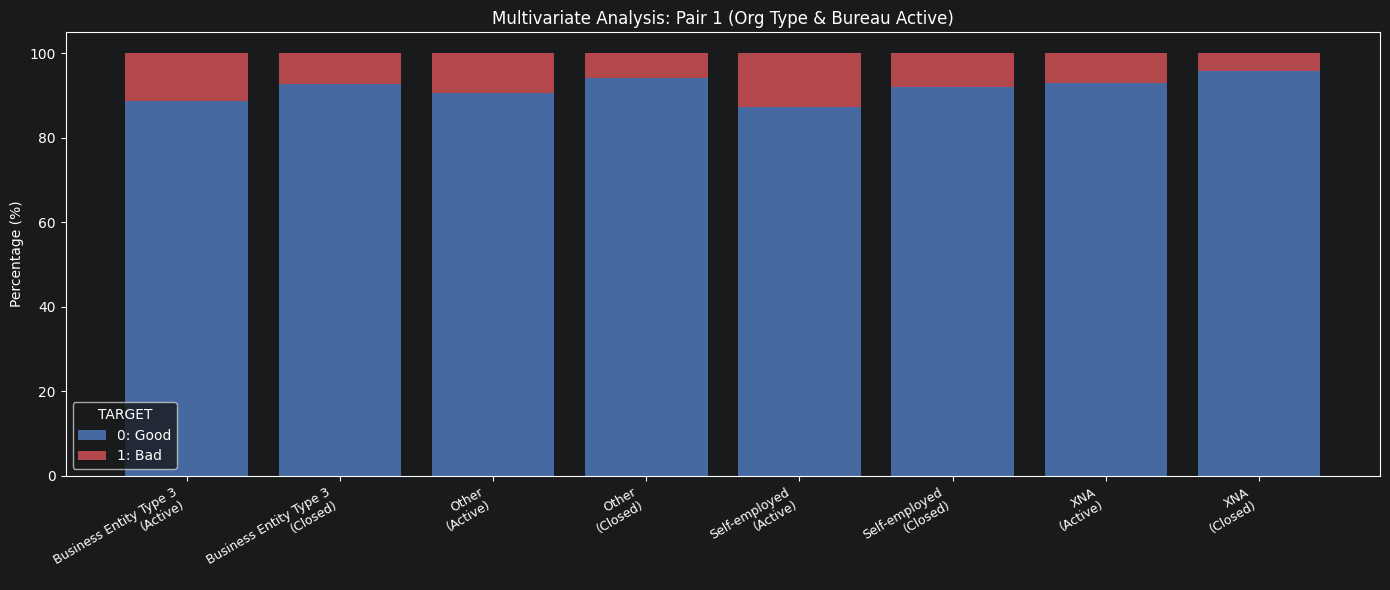

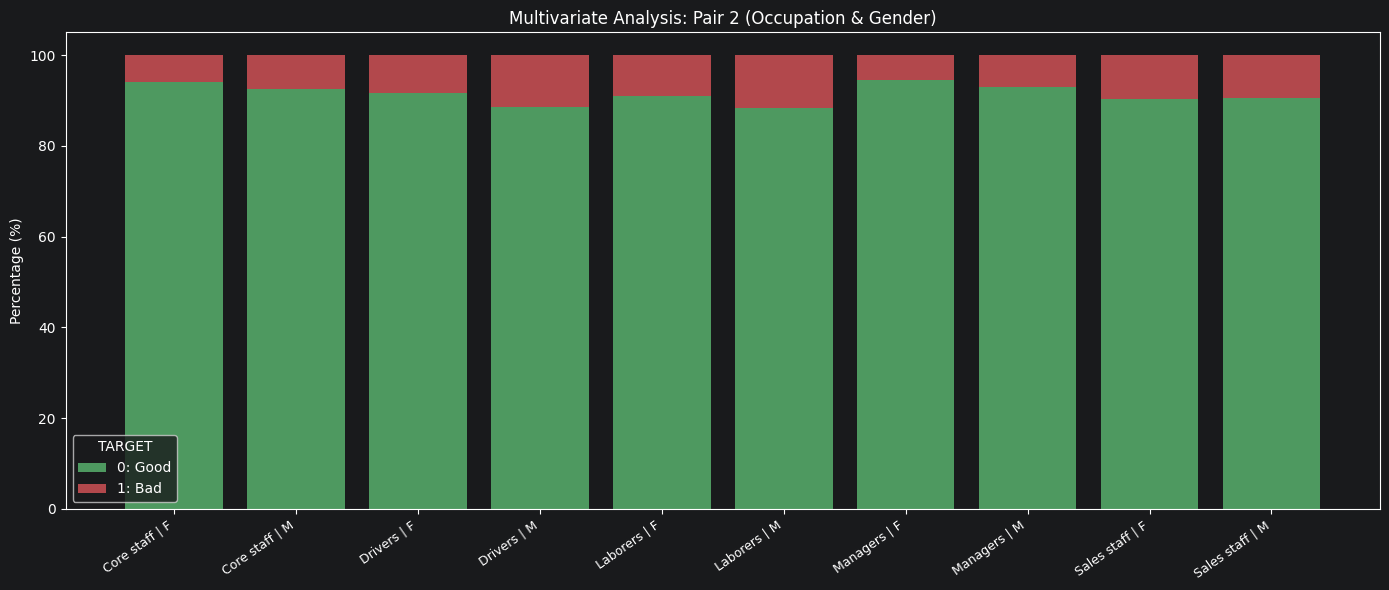

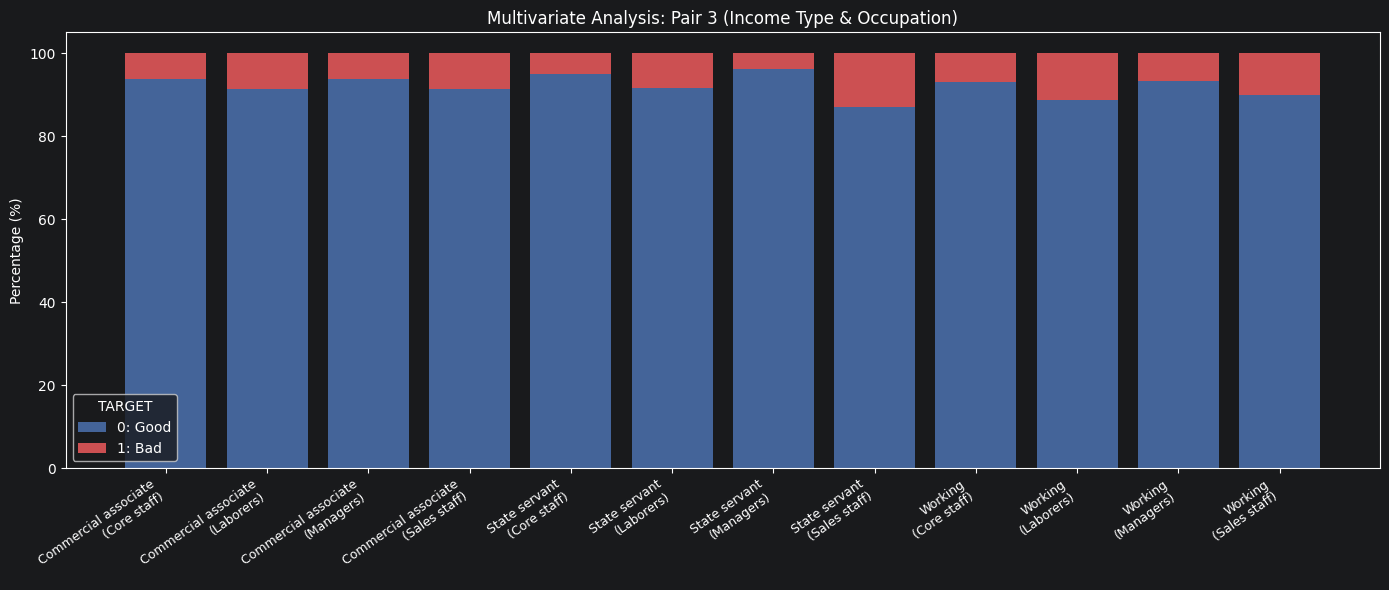

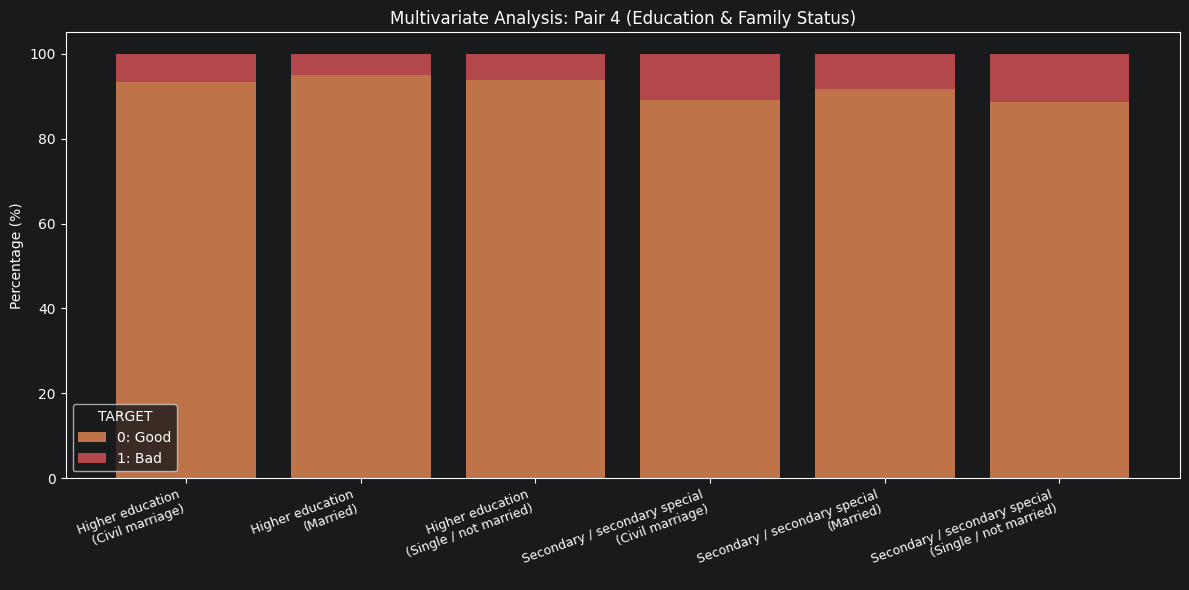

In [10]:
import matplotlib.pyplot as plt

# Khởi tạo ma trận phẳng phục vụ phân tích đa biến
df_multivariate = df_final_eda_matrix.copy()
df_multivariate['TARGET'] = df_multivariate['TARGET'].astype(int)

# TODO: Pair 1 - Org Type & Bureau Active
def run_analysis_pair_1(df):
    top_orgs = df['ORGANIZATION_TYPE'].value_counts().head(4).index
    valid_active = ['Active', 'Closed']
    df_f1 = df[(df['ORGANIZATION_TYPE'].isin(top_orgs)) & (df['BUREAU_CREDIT_ACTIVE'].isin(valid_active))]

    pivot1 = df_f1.groupby(['ORGANIZATION_TYPE', 'BUREAU_CREDIT_ACTIVE'])['TARGET'].value_counts(normalize=True).unstack().fillna(0) * 100
    pivot1 = pivot1.reset_index()
    pivot1['LABELS'] = pivot1['ORGANIZATION_TYPE'] + "\n(" + pivot1['BUREAU_CREDIT_ACTIVE'] + ")"

    plt.figure(figsize=(14, 6))
    plt.bar(pivot1['LABELS'], pivot1[0], color='#4c72b0', alpha=0.9, label='0: Good')
    plt.bar(pivot1['LABELS'], pivot1[1], bottom=pivot1[0], color='#c44e52', alpha=0.9, label='1: Bad')
    plt.xticks(rotation=30, ha='right', fontsize=9)
    plt.ylabel("Percentage (%)")
    plt.title("Multivariate Analysis: Pair 1 (Org Type & Bureau Active)")
    plt.legend(title="TARGET", loc='lower left')
    plt.tight_layout()
    plt.show()

# TODO: Pair 2 - Occupation & Gender
def run_analysis_pair_2(df):
    top_jobs = df['OCCUPATION_TYPE'].value_counts().head(5).index
    df_f2 = df[(df['OCCUPATION_TYPE'].isin(top_jobs)) & (df['CODE_GENDER'].isin(['M', 'F']))]

    pivot2 = df_f2.groupby(['OCCUPATION_TYPE', 'CODE_GENDER'])['TARGET'].value_counts(normalize=True).unstack().fillna(0) * 100
    pivot2 = pivot2.reset_index()
    pivot2['LABELS'] = pivot2['OCCUPATION_TYPE'] + " | " + pivot2['CODE_GENDER']

    plt.figure(figsize=(14, 6))
    plt.bar(pivot2['LABELS'], pivot2[0], color='#55a868', alpha=0.9, label='0: Good')
    plt.bar(pivot2['LABELS'], pivot2[1], bottom=pivot2[0], color='#c44e52', alpha=0.9, label='1: Bad')
    plt.xticks(rotation=35, ha='right', fontsize=9)
    plt.ylabel("Percentage (%)")
    plt.title("Multivariate Analysis: Pair 2 (Occupation & Gender)")
    plt.legend(title="TARGET", loc='lower left')
    plt.tight_layout()
    plt.show()

# TODO: Pair 3 - Income Type & Occupation
def run_analysis_pair_3(df):
    main_incomes = ['Working', 'Commercial associate', 'State servant']
    top_jobs = df['OCCUPATION_TYPE'].value_counts().head(4).index
    df_f3 = df[(df['NAME_INCOME_TYPE'].isin(main_incomes)) & (df['OCCUPATION_TYPE'].isin(top_jobs))]

    pivot3 = df_f3.groupby(['NAME_INCOME_TYPE', 'OCCUPATION_TYPE'])['TARGET'].value_counts(normalize=True).unstack().fillna(0) * 100
    pivot3 = pivot3.reset_index()
    pivot3['LABELS'] = pivot3['NAME_INCOME_TYPE'] + "\n(" + pivot3['OCCUPATION_TYPE'] + ")"

    plt.figure(figsize=(14, 6))
    plt.bar(pivot3['LABELS'], pivot3[0], color='#4c72b0', alpha=0.85, label='0: Good')
    plt.bar(pivot3['LABELS'], pivot3[1], bottom=pivot3[0], color='#e15759', alpha=0.9, label='1: Bad')
    plt.xticks(rotation=35, ha='right', fontsize=9)
    plt.ylabel("Percentage (%)")
    plt.title("Multivariate Analysis: Pair 3 (Income Type & Occupation)")
    plt.legend(title="TARGET")
    plt.tight_layout()
    plt.show()

# TODO: Pair 4 - Education & Family Status
def run_analysis_pair_4(df):
    main_edu = ['Higher education', 'Secondary / secondary special']
    main_fam = ['Married', 'Single / not married', 'Civil marriage']
    df_f4 = df[(df['NAME_EDUCATION_TYPE'].isin(main_edu)) & (df['NAME_FAMILY_STATUS'].isin(main_fam))]

    pivot4 = df_f4.groupby(['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS'])['TARGET'].value_counts(normalize=True).unstack().fillna(0) * 100
    pivot4 = pivot4.reset_index()
    pivot4['LABELS'] = pivot4['NAME_EDUCATION_TYPE'] + "\n(" + pivot4['NAME_FAMILY_STATUS'] + ")"

    plt.figure(figsize=(12, 6))
    plt.bar(pivot4['LABELS'], pivot4[0], color='#dd8452', alpha=0.85, label='0: Good')
    plt.bar(pivot4['LABELS'], pivot4[1], bottom=pivot4[0], color='#c44e52', alpha=0.9, label='1: Bad')
    plt.xticks(rotation=20, ha='right', fontsize=9)
    plt.ylabel("Percentage (%)")
    plt.title("Multivariate Analysis: Pair 4 (Education & Family Status)")
    plt.legend(title="TARGET")
    plt.tight_layout()
    plt.show()

# Kích hoạt thực thi chuỗi hàm phân tích đa biến
if __name__ == '__main__':
    run_analysis_pair_1(df_multivariate)
    run_analysis_pair_2(df_multivariate)
    run_analysis_pair_3(df_multivariate)
    run_analysis_pair_4(df_multivariate)

# Cặp 1: Loại hình tổ chức (ORGANIZATION_TYPE) và Trạng thái dư nợ ngoài (BUREAU_CREDIT_ACTIVE)
Câu hỏi đặt ra trước khi phân tích: Khách hàng làm việc ở cơ quan nào thì có khả năng gánh được các khoản vay chưa tất toán bên ngoài (Active) mà không bị bùng nợ khi vay tiền ở hệ thống nội bộ của mình?

Lý do chọn cặp này: Biến nơi làm việc có không gian nhãn quá rộng (hơn 50 nhóm). Nếu để đứng một mình dữ liệu sẽ bị vụn. Mình ép nó bắt cặp với biến trạng thái CIC bên ngoài (chỉ có 2 nhãn lớn) để chặn bớt hiện tượng dữ liệu thưa thớt (Data Sparsity). Cách làm này giúp tạo ra các ô tổ hợp có mật độ xác suất rõ ràng, giúp mô hình cây về sau dễ cắt nhánh quyết định mà không bị học vẹt (Overfitting).

Góc nhìn nghiệp vụ: Tổ hợp này giúp mình so sánh chéo giữa độ ổn định của công việc hiện tại và áp lực nợ nần thực tế họ đang gánh ở các ngân hàng khác đối thủ, từ đó dự báo chính xác hơn hành vi nợ xấu.

# Cặp 2: Tính chất nghề nghiệp (OCCUPATION_TYPE) và Giới tính (CODE_GENDER)
Câu hỏi đặt ra trước khi phân tích: Nếu đặt yếu tố giới tính vào bối cảnh áp lực của từng công việc cụ thể, tỷ lệ nợ tốt (0) và nợ xấu (1) có bị dịch chuyển hay xuất hiện đột biến nào không?

Lý do chọn cặp này: Biến giới tính là biến nhị phân rất sạch, không có dữ liệu lỗi hay trị ngoại lai (Outliers). Khi chập nó với biến nghề nghiệp, giới tính sẽ hoạt động như một màng lọc để tăng độ thuần khiết (Purity) cho các phân lớp dữ liệu, giúp các thuật toán như XGBoost phân loại nhãn nhạy bén hơn.

Góc nhìn nghiệp vụ: Thực tế cho thấy cùng một ngành nghề (ví dụ: lao động phổ thông) nhưng hành vi tài chính giữa nam và nữ có sự phân hóa rất mạnh. Việc kết hợp này giúp mình phác họa sâu hơn chân dung hành vi của khách hàng.

# Cặp 3: Nguồn thu nhập (NAME_INCOME_TYPE) và Tính chất nghề nghiệp (OCCUPATION_TYPE)
Câu hỏi đặt ra trước khi phân tích: Liệu khả năng trả nợ đều đặn hàng tháng có bị ảnh hưởng lớn do sự lệch pha giữa hình thức nhận tiền và công việc thực tế của khách hàng không?

Lý do chọn cặp này: Đây là hai biến chữ có chỉ số sức mạnh dán nhãn (IV) đứng hàng top đầu bảng. Việc kết hợp chúng giúp mình tạo ra một không gian đặc trưng có tính tương hỗ cao để phục vụ bài toán phân loại nhị phân.

Góc nhìn nghiệp vụ: Trong quản trị rủi ro ngân hàng, tính bền vững của dòng tiền quan trọng hơn tổng thu nhập tĩnh. Một người đi làm tự do nhưng làm quản lý sẽ có rủi ro đứt gãy dòng tiền thấp hơn nhiều so với một người làm lao động phổ thông. Cặp này giúp mình lọc ra các phân khúc tài chính dễ bị tổn thương nhất.

# Cặp 4: Trình độ học vấn (NAME_EDUCATION_TYPE) và Tình trạng hôn nhân (NAME_FAMILY_STATUS)
Câu hỏi đặt ra trước khi phân tích: Trách nhiệm với gia đình kết hợp với mức độ nhận thức về điểm tín dụng (Học vấn) có tạo ra một màng lọc tự nhiên giúp giảm bớt rủi ro đạo đức không?

Lý do chọn cặp này: Việc lồng ghép hai biến nhân khẩu học nền tảng giúp mình kiểm tra được các đường biên phân phối xác suất một cách thuần túy, loại bỏ hoàn toàn các lỗi nhiễu từ các giá trị dị biệt (Outliers) giống như khi phân tích biến số liên tục.

Góc nhìn nghiệp vụ: Tổ hợp này đánh giá về "Ý thức muốn trả nợ" (Willingness to pay). Người có học vấn cao thường sợ bị dính vết nợ xấu trên CIC, kết hợp với ràng buộc hôn nhân sẽ khiến họ chi tiêu có kế hoạch và ít xù nợ hơn, giúp mô hình phân tách rõ ràng ranh giới giữa người tốt và người xấu.

# KẾT LUẬN CHƯƠNG EDA VÀ ĐỊNH HƯỚNG TIẾP THEO
Đến bước này, bức tranh tổng quan về cấu trúc dữ liệu của dự án đã hoàn toàn tường minh. Việc phân tích đơn biến và đa biến lồng ghép đã giúp mình định danh được các thuộc tính mạnh nhất, đồng thời bóc tách thành công các phân khúc có mật độ rủi ro nợ xấu tập trung cao bằng số liệu thực tế. Yếu tố nhiễu hay rủi ro thưa thớt dữ liệu cũng đã được kiểm soát tốt.

Vì đặc thù bộ dữ liệu Home Credit có hiện tượng mất cân bằng nhãn rất nặng (~92% nhãn 0 và chỉ ~8% nhãn 1), mình xin phép khép lại giai đoạn EDA tại đây để chuyển sang quy trình Tiền xử lý (Mã hóa đặc trưng, xử lý mất cân bằng bằng scale_pos_weight/SMOTE) để bắt đầu huấn luyện và chạy thử các mô hình phân loại nhị phân như XGBoost và LightGBM theo đúng tiến độ.